In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
x_train_scaled=pd.read_csv("x_train_scaled.csv")
x_test_scaled=pd.read_csv("x_test_scaled.csv")
x_train=pd.read_csv("x_train.csv")
x_test=pd.read_csv("x_test.csv")
y_train=pd.read_csv("y_train.csv")
y_test=pd.read_csv("y_test.csv")

In [9]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)
lr_pred=lr.predict(x_test_scaled)

C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,lr_pred)

0.745

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.60      0.47      0.52        60
           1       0.79      0.86      0.83       140

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.73      0.74      0.74       200



In [14]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [15]:
accuracy_score(y_test,rf_pred)

0.775

In [16]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.66      0.52      0.58        60
           1       0.81      0.89      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



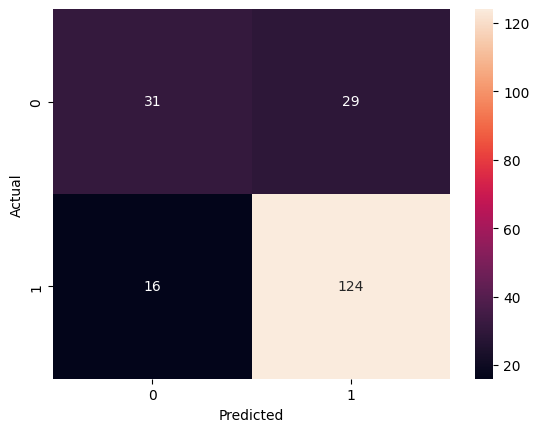

In [19]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,rf_pred)
sns.heatmap(cm,
            annot=True,
            fmt="d"
           )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
importance=pd.DataFrame({
    "Feature":x_train.columns,
    "Importance":rf.feature_importances_
})
importance=importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
2,Credit amount,0.232244
0,Age,0.172699
3,Duration,0.158804
13,Checking account_unknown,0.084674
1,Job,0.057274
10,Saving accounts_unknown,0.033901
4,Sex_male,0.031210
14,Purpose_car,0.030620
11,Checking account_moderate,0.027170
18,Purpose_radio/TV,0.025341


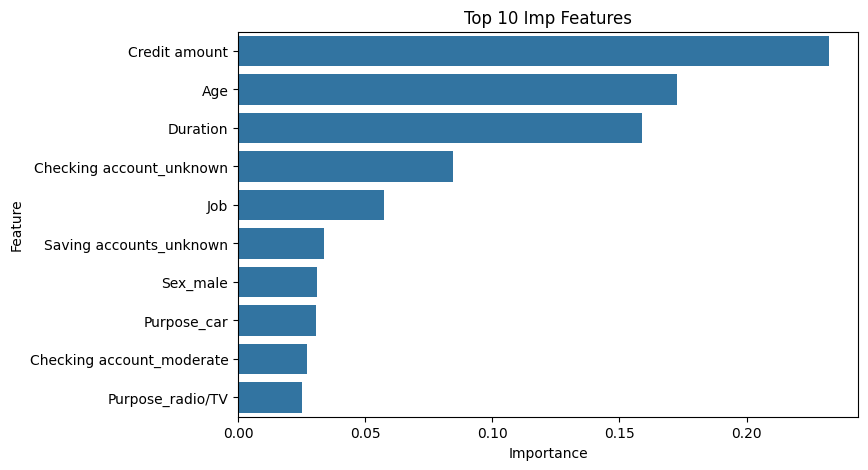

In [28]:
top=importance.head(10)
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
data=top
)
plt.title("Top 10 Imp Features")
plt.show()

In [32]:
results=pd.DataFrame({
    "Model":["Logistic Regression",
             "Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred)
    ]
})
results

,Model,Accuracy
0,Logistic Regression,0.745
1,Random Forest,0.775


In [33]:
import joblib 
joblib.dump(
    rf,
    "../models/credit_risk_model.pkl"
)

['../models/credit_risk_model.pkl']

In [37]:
rf_accuracy=accuracy_score(y_test,rf_pred)
print(rf_accuracy)

0.775


In [42]:
rf2=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf2.fit(x_train,y_train)
rf2_pred=rf2.predict(x_test)

C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [41]:
accuracy_score(y_test,rf2_pred)

0.745

In [48]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15],
    "min_samples_split":[2,5,10]
}

grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(x_train,y_train)

grid.best_params_
grid.best_score_


C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


np.float64(0.74375)

In [49]:
best_rf=grid.best_estimator_
best_pred=best_rf.predict(x_test)
accuracy_score(y_test,best_pred)

0.77

In [52]:
from sklearn.metrics import roc_auc_score
probs=best_rf.predict_proba(x_test)[:,1]
roc_auc_score(y_test,probs)

0.7591666666666667

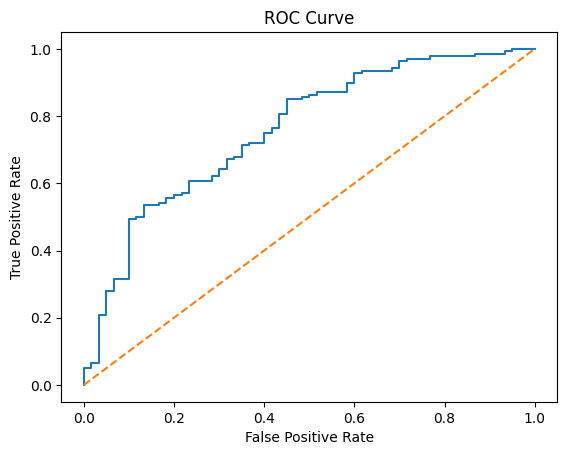

In [54]:
from sklearn.metrics import roc_curve
fpr,tpr,_ = roc_curve(y_test,probs)

plt.plot(fpr,tpr)
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [56]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(
    best_rf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(scores)
print(scores.mean())

C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\rohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

[0.7875  0.7     0.75    0.71875 0.7625 ]
0.74375


In [57]:
import joblib
joblib.dump(
    best_rf,
    "../models/final_credit_risk_model.pkl"
)

['../models/final_credit_risk_model.pkl']

In [6]:
import joblib
joblib.dump(
    x_train.columns,
    "../models/columns.pkl"
)

['../models/columns.pkl']

In [7]:
import os

os.listdir("../models")


['.ipynb_checkpoints',
 'columns.pkl',
 'credit_risk_model.pkl',
 'final_credit_risk_model.pkl']